In [1]:
import sys
import os
import yaml
from tqdm import tqdm
import matplotlib.pyplot as plt
import numpy as np
import pickle
import torch

sys.path.append(os.path.join(os.getcwd(), ".."))
from models.RL import environment, DQN
from models.experiment_model import StateSpaceModel

In [ ]:
MAX_EPISODE = 50000
MAX_TIME_PER_EPISODE = 60*15
DT = 3
MAX_ITER_PER_EPISODE = int(MAX_TIME_PER_EPISODE/DT) #300
MINIBATCH_SIZE = 256

In [3]:
with open(r"..\config\DQN.yaml") as f:
    config = yaml.safe_load(f)

network_arg = config["network_arg"]
lr = config["lr"]
replay_capa = config["replay_capa"]

In [4]:
agent = DQN(network_arg, lr, replay_capa)
print(agent.Q_func, agent.target_func)

SingleNetwork(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=37, bias=True)
  )
) SingleNetwork(
  (model): Sequential(
    (0): Linear(in_features=2, out_features=256, bias=True)
    (1): ReLU()
    (2): Linear(in_features=256, out_features=256, bias=True)
    (3): ReLU()
    (4): Linear(in_features=256, out_features=37, bias=True)
  )
)


In [5]:
def evaluate(agent, num_episodes=10):
    eval_env = environment()
    total_rewards = []

    agent.Q_func.eval()
    agent.target_func.eval()

    for ep in range(num_episodes):
        state = eval_env.reset()
        episode_reward = 0

        for _ in range(MAX_ITER_PER_EPISODE):
            with torch.no_grad():
                action = agent.greedy_action(state)
            next_state, reward, terminated = eval_env.step(action, dt=DT)

            episode_reward += reward
            state = next_state

            if terminated:
                break

        total_rewards.append(episode_reward)

    agent.Q_func.train()
    agent.target_func.train()
    
    return total_rewards

In [6]:
global_step = 0
env = environment()
eval_episodes = []
eval_means    = []
eval_stds     = []

for episode in tqdm(range(MAX_EPISODE)):
    state = env.reset()

    for _ in range(MAX_ITER_PER_EPISODE):
        action = agent.epsilon_greedy_action(global_step, state)
        next_state, reward, terminated = env.step(action, dt=DT)
        agent.store_transition(state, action, reward, next_state, terminated)
        global_step += 1

        if len(agent.replay_buffer) > 2*MINIBATCH_SIZE:
            agent.update(MINIBATCH_SIZE)

        state = next_state
        if terminated:
            break

    if episode % 100 == 0:
        rewards = evaluate(agent, num_episodes=10)
        eval_episodes.append(episode)
        eval_means.append(np.mean(rewards))
        eval_stds.append(np.std(rewards))

100%|██████████| 50000/50000 [18:05:27<00:00,  1.30s/it]   


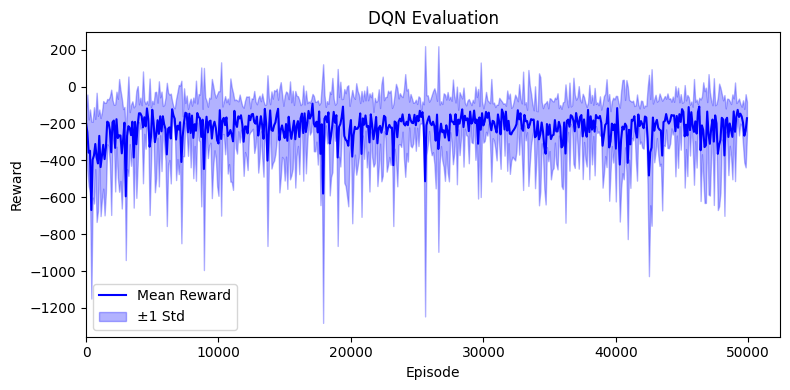

In [7]:
means = np.array(eval_means)
stds  = np.array(eval_stds)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(eval_episodes, means, color="blue", label="Mean Reward")
ax.fill_between(eval_episodes, means - stds, means + stds, alpha=0.3, color="blue", label="±1 Std")
ax.set_xlabel("Episode")
ax.set_ylabel("Reward")
ax.set_xlim(left=0)
ax.set_title("DQN Evaluation")
ax.legend()
plt.tight_layout()
plt.show()

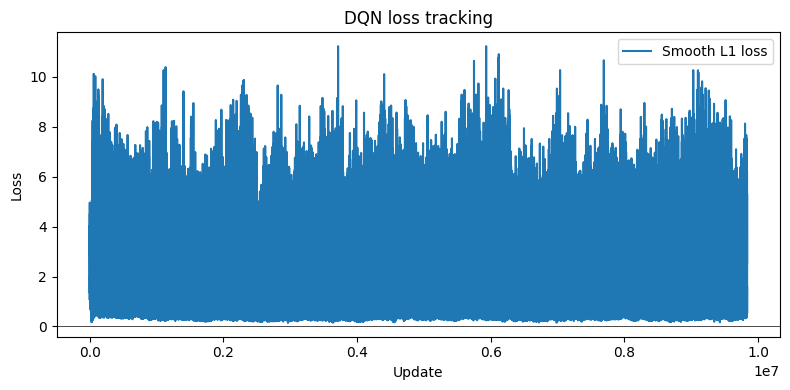

In [8]:
loss_history = np.array(agent.loss_history)

fig, ax = plt.subplots(figsize=(8,4))
ax.plot(loss_history, label="Smooth L1 loss")
ax.set_xlabel("Update")
ax.set_ylabel("Loss")
ax.set_title("DQN loss tracking")
ax.legend()
ax.axhline(y=0, color="k", lw=0.5)
plt.tight_layout()
plt.show()

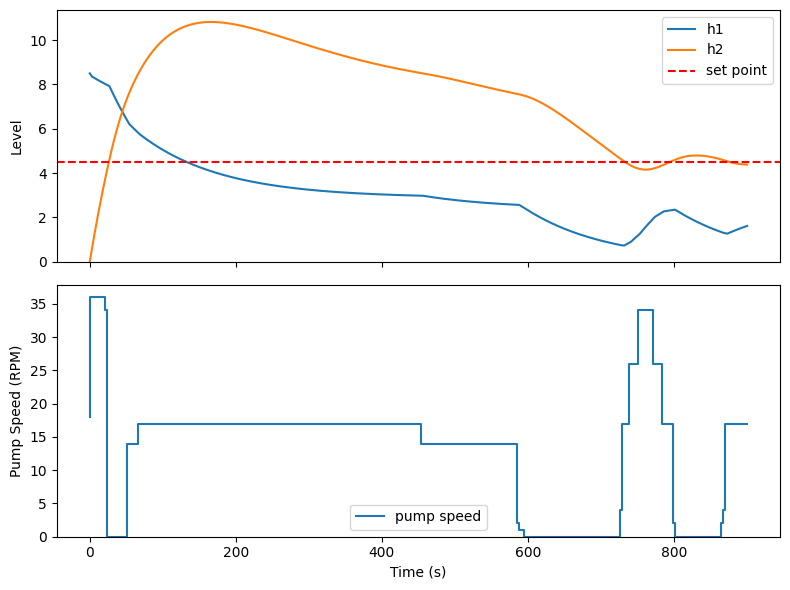

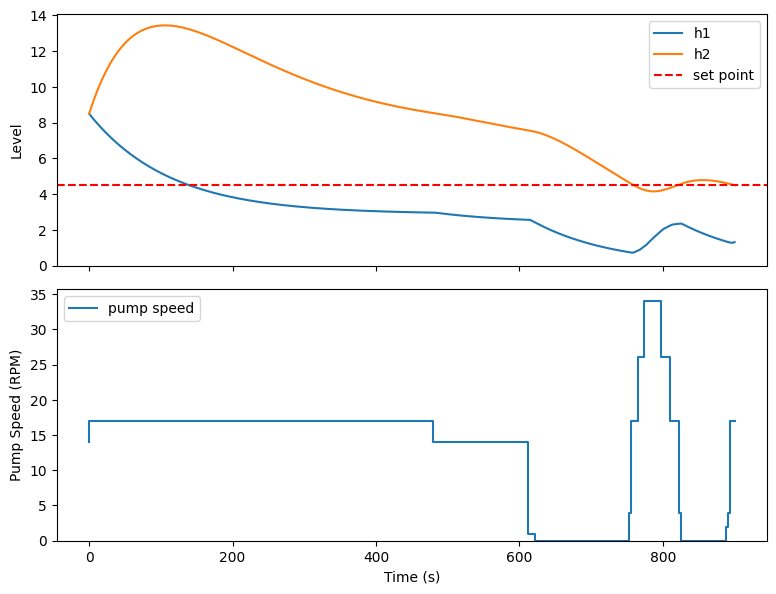

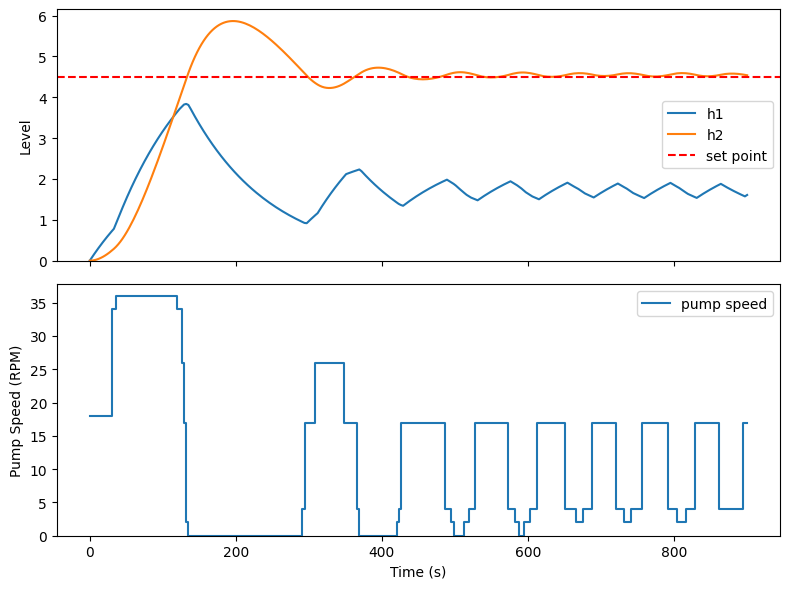

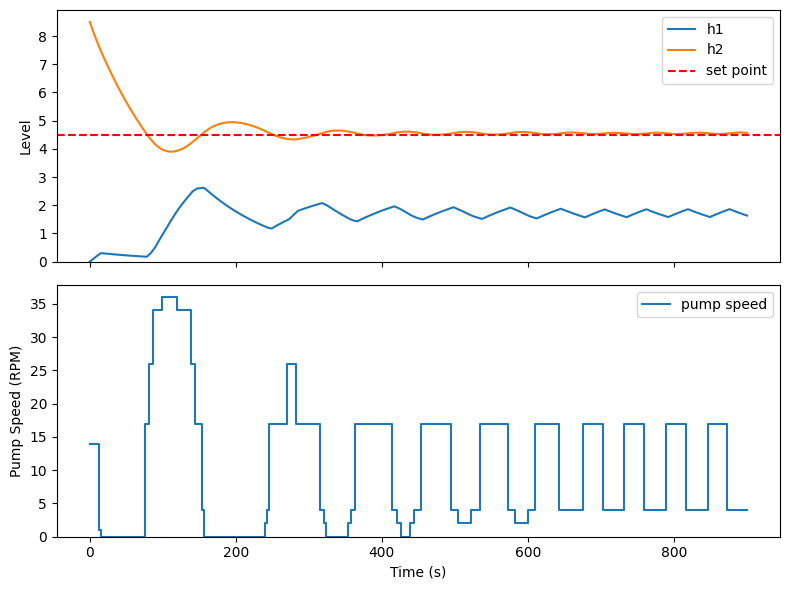

In [9]:
SET_POINT = 4.5
MAX_H = 8.5
INITIAL_STATE = np.array([[8.5, 8.5, 0, 0], 
                          [0, 8.5, 0, 8.5]])

agent.Q_func.eval()
agent.target_func.eval()

with open(r"..\parameters\state_space_param.pickle", "rb") as f:
    param = pickle.load(f)
A, B, C, D = param["A"], param["B"], param["C"], param["D"]

environment = StateSpaceModel(pred_x0=False)

with torch.no_grad():
    for i in range(INITIAL_STATE.shape[1]):
        h1_trajectory = []
        h2_trajectory = []
        action_trajectory = []
        time_trajectory = []
        xk = INITIAL_STATE[:,i]
        h1_trajectory.append(xk[0].item())
        h2_trajectory.append(xk[1].item())
        for j in range(MAX_ITER_PER_EPISODE):
            input_state = np.array((xk[1].item(), SET_POINT))
            norm_state = input_state/MAX_H
            action = agent.greedy_action(norm_state)
            action_trajectory.append(action)
            time_trajectory.append(j*DT)
            xk, _ = environment.step_pred(A, B, C, D, xk, action, dt=DT)
            h1_trajectory.append(xk[0].item())
            h2_trajectory.append(xk[1].item())
        time_trajectory.append((j+1)*DT)
        input_state = np.array((xk[1].item(), SET_POINT))
        norm_state = input_state/MAX_H
        action = agent.greedy_action(norm_state)
        action_trajectory.append(action)

        fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(8, 6), sharex=True)

        ax1.plot(time_trajectory, h1_trajectory, label="h1")
        ax1.plot(time_trajectory, h2_trajectory, label="h2")
        ax1.axhline(y=SET_POINT, label="set point", ls="--", color="red")  # cleaner for constant lines
        ax1.set_ylabel("Level")
        ax1.set_ylim(bottom=0)
        ax1.legend()

        ax2.step(time_trajectory, action_trajectory, label="pump speed")
        ax2.set_ylabel("Pump Speed (RPM)")
        ax2.set_xlabel("Time (s)")
        ax2.set_ylim(bottom=0)
        ax2.legend()

        plt.tight_layout()
        plt.show()

In [10]:
torch.save(agent.Q_func.state_dict(), r"..\parameters\DQN.pt")